In [23]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import sys
from pathlib import Path


PROJECT_ROOT = Path("/content/drive/MyDrive/master-thesis").resolve()
SRC_PATH = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / 'data/13_years'

os.chdir(PROJECT_ROOT)

Mounted at /content/drive


In [24]:
from sklearn.metrics import mean_squared_error
from math import sqrt
import pandas as pd
import sys
from notebooks.utils import get_predictions, get_predictions_transformer, get_predictions_quarterly_models, plot_average_predictions

In [25]:
tickers = ['GOOGL', 'AMZN', 'AAPL', 'PEP', 'JNJ', 'PFE', 'MRK', 'ABBV', 'PG', 'KO',
           'WMT', 'JPM', 'BAC', 'GS', 'V', 'XOM', 'CVX', 'COP', 'BP', 'BA',
           'MMM', 'HON', 'GE', 'T', 'VZ', 'TMUS', 'HSY', 'DUK', 'SO', 'EXC', 'AEP',
           'AMT', 'PLD', 'SPG', 'BHP', 'RIO', 'VALE', 'FCX']
           
simulation_start_date = '2021-01-01'
simulation_end_date = '2023-10-23'

sequence_length = 50

quarterly_data_start_date = '2013-01-01'
data_end_date = '2023-10-23'

# LSTM 13 years training

In [26]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_13_years'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_13_years'

In [27]:
predictions, actuals = get_predictions(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    MODEL_DIR,
    use_partition_dataset=False,
)

Processing GOOGL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing AMZN...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing AAPL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing PEP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing JNJ...


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing BHP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing RIO...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Processing VALE...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing FCX...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [28]:
def calculate_rmse_for_all_tickers(actuals, predictions):
    rmse_values = {}
    for ticker in actuals.keys():
        actual = actuals[ticker]
        pred = predictions[ticker]
        rmse = sqrt(mean_squared_error(actual, pred))
        rmse_values[ticker] = rmse
        print(f"RMSE for {ticker}: {rmse}")
    return rmse_values

rmse_values = calculate_rmse_for_all_tickers(actuals, predictions)

RMSE for GOOGL: 3.6404304343858573
RMSE for AMZN: 4.8564572083304
RMSE for AAPL: 4.998041423272918
RMSE for PEP: 2.48791467859992
RMSE for JNJ: 2.439638894879398
RMSE for PFE: 1.158512013199174
RMSE for MRK: 1.7571319197449538
RMSE for ABBV: 2.823906627299002
RMSE for PG: 2.3138162590750317
RMSE for KO: 0.9024640564793718
RMSE for WMT: 0.9238424658043776
RMSE for JPM: 3.15491135730674
RMSE for BAC: 1.0194328925383063
RMSE for GS: 11.970571176333143
RMSE for V: 4.897453311628761
RMSE for XOM: 2.9098462636754494
RMSE for CVX: 4.9398110829396575
RMSE for COP: 3.799124347698207
RMSE for BP: 1.3497180884524134
RMSE for BA: 6.593590516925068
RMSE for MMM: 2.7540941133117176
RMSE for HON: 3.6757965710469342
RMSE for GE: 1.7861800760392728
RMSE for T: 0.4531324372986148
RMSE for VZ: 0.8246061072650808
RMSE for TMUS: 2.9093832917083424
RMSE for HSY: 3.653932406071959
RMSE for DUK: 1.8052696790222642
RMSE for SO: 1.208998489600716
RMSE for EXC: 1.1189028850211638
RMSE for AEP: 1.6357080062556801

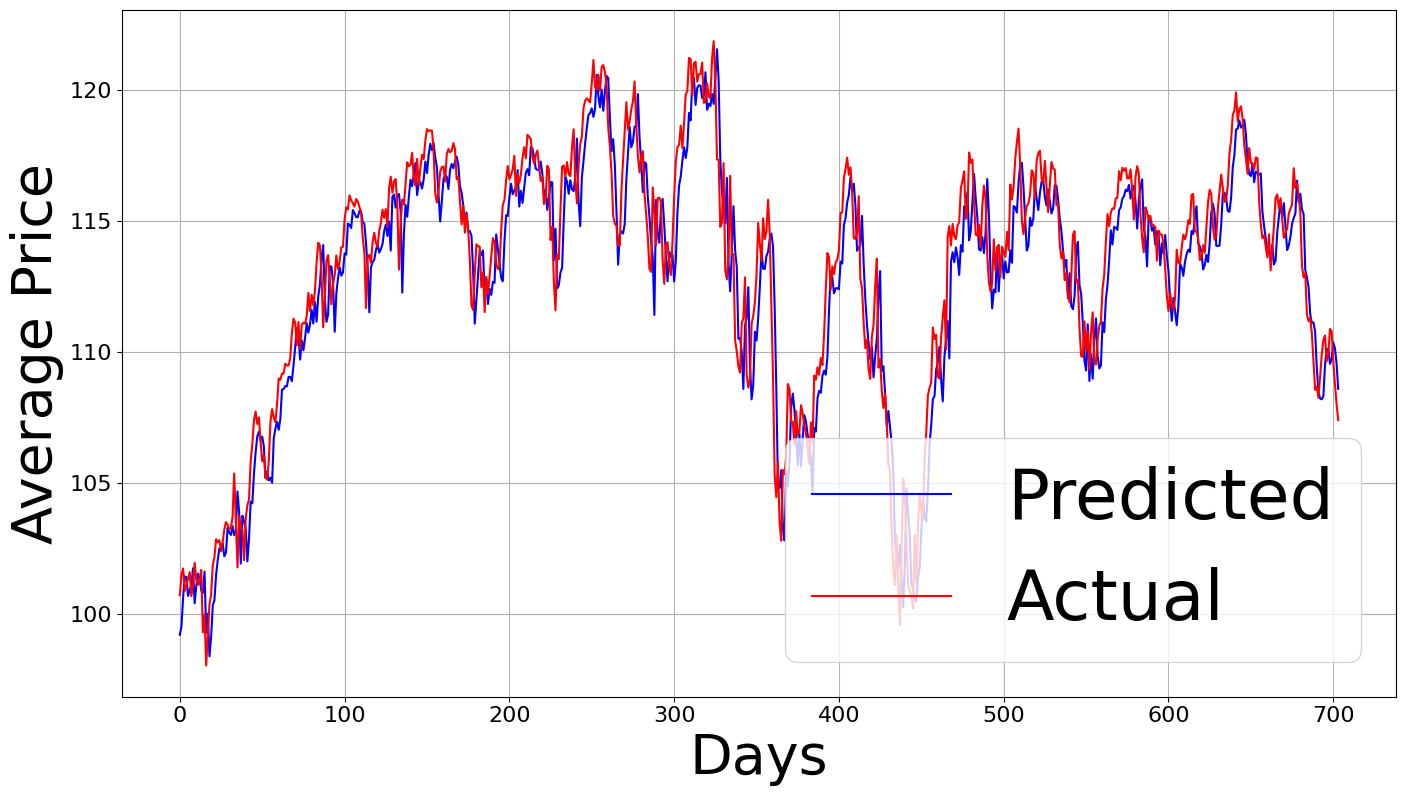

In [29]:
plot_average_predictions(predictions, actuals, PLOTS_DIR)

# LSTM 3 years training

In [8]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_3_years'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_3_years'

In [ ]:
predictions, actuals = get_predictions(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    MODEL_DIR,
    use_partition_dataset=False,
)

In [10]:
def calculate_rmse_for_all_tickers(actuals, predictions):
    rmse_values = {}
    for ticker in actuals.keys():
        actual = actuals[ticker]
        pred = predictions[ticker]
        rmse = sqrt(mean_squared_error(actual, pred))
        rmse_values[ticker] = rmse
        print(f"RMSE for {ticker}: {rmse}")
    return rmse_values

rmse_values = calculate_rmse_for_all_tickers(actuals, predictions)

RMSE for GOOGL: 3.282430669732701
RMSE for AMZN: 5.1578449826825885
RMSE for AAPL: 3.9265230759193046
RMSE for PEP: 2.6820104111958583
RMSE for JNJ: 2.349984769197647
RMSE for PFE: 1.0974179571733942
RMSE for MRK: 1.8095492012897498
RMSE for ABBV: 3.300058394278398
RMSE for PG: 2.393024122888648
RMSE for KO: 0.8839215544554885
RMSE for WMT: 0.9838244560942563
RMSE for JPM: 3.8446146088280493
RMSE for BAC: 0.9565455945687448
RMSE for GS: 11.869186447653341
RMSE for V: 4.820331840635879
RMSE for XOM: 3.2852562772824454
RMSE for CVX: 4.620961649969575
RMSE for COP: 5.920085105777549
RMSE for BP: 0.9511352123919198
RMSE for BA: 6.3754324677373
RMSE for MMM: 3.7157949281543177
RMSE for HON: 3.5407331297532165
RMSE for GE: 3.053053506267718
RMSE for T: 0.6399980661258734
RMSE for VZ: 0.8057987344718754
RMSE for TMUS: 3.4497089898883053
RMSE for HSY: 4.160637806612278
RMSE for DUK: 1.9138815437516274
RMSE for SO: 1.164440866608646
RMSE for EXC: 0.8297082925437502
RMSE for AEP: 1.5968447861737

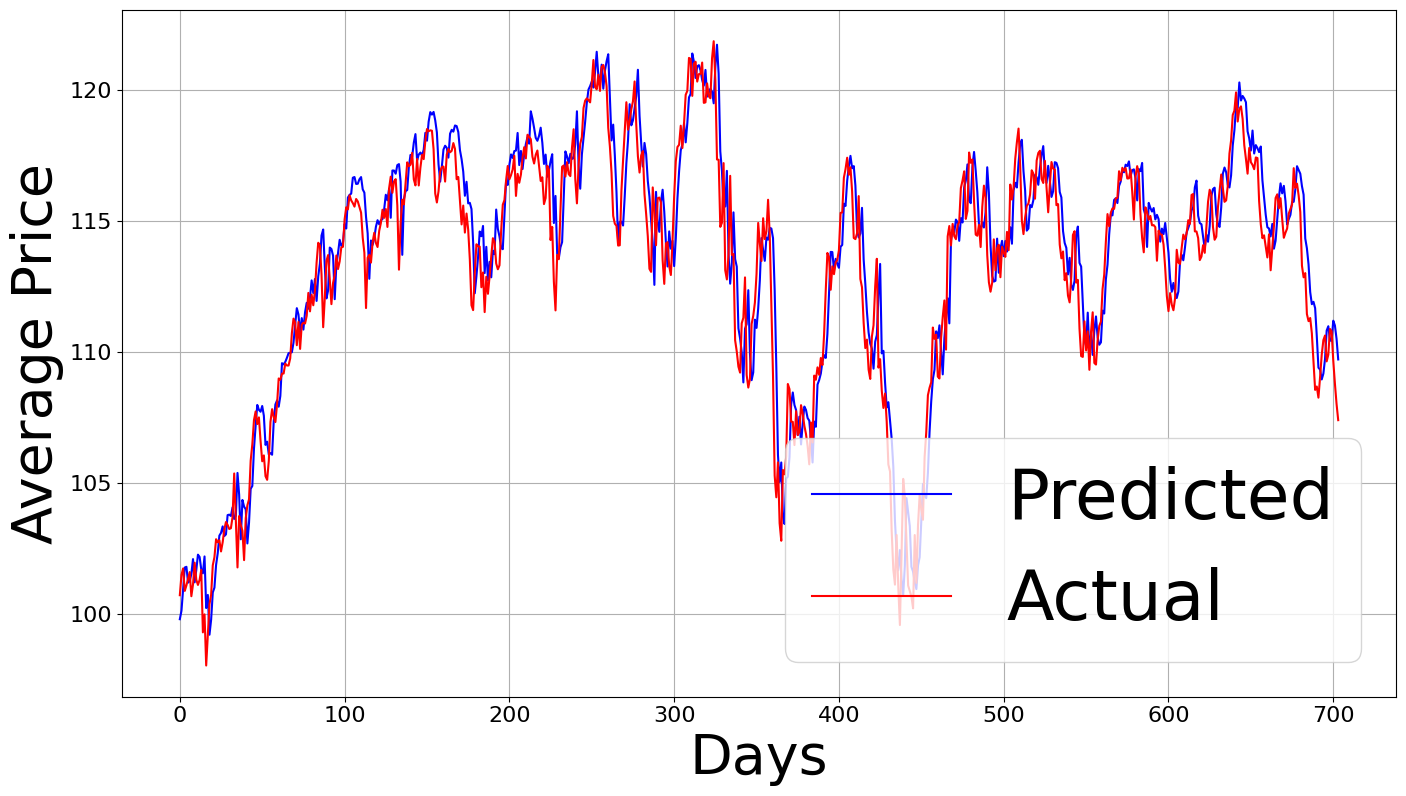

In [11]:
plot_average_predictions(predictions, actuals, PLOTS_DIR)

# LSTM quarterly cumulative retrain

In [12]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_cumulative'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_cumulative'

In [ ]:
predictions, actuals = get_predictions_quarterly_models(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    model_folder=MODEL_DIR,
    data_start=quarterly_data_start_date,
    train_mode="cumulative"
)

In [ ]:
def calculate_rmse_for_all_tickers(actuals, predictions):
    rmse_values = {}
    for ticker in actuals.keys():
        actual = actuals[ticker]
        pred = predictions[ticker]
        rmse = sqrt(mean_squared_error(actual, pred))
        rmse_values[ticker] = rmse
        print(f"RMSE for {ticker}: {rmse}")
    return rmse_values

rmse_values = calculate_rmse_for_all_tickers(actuals, predictions)

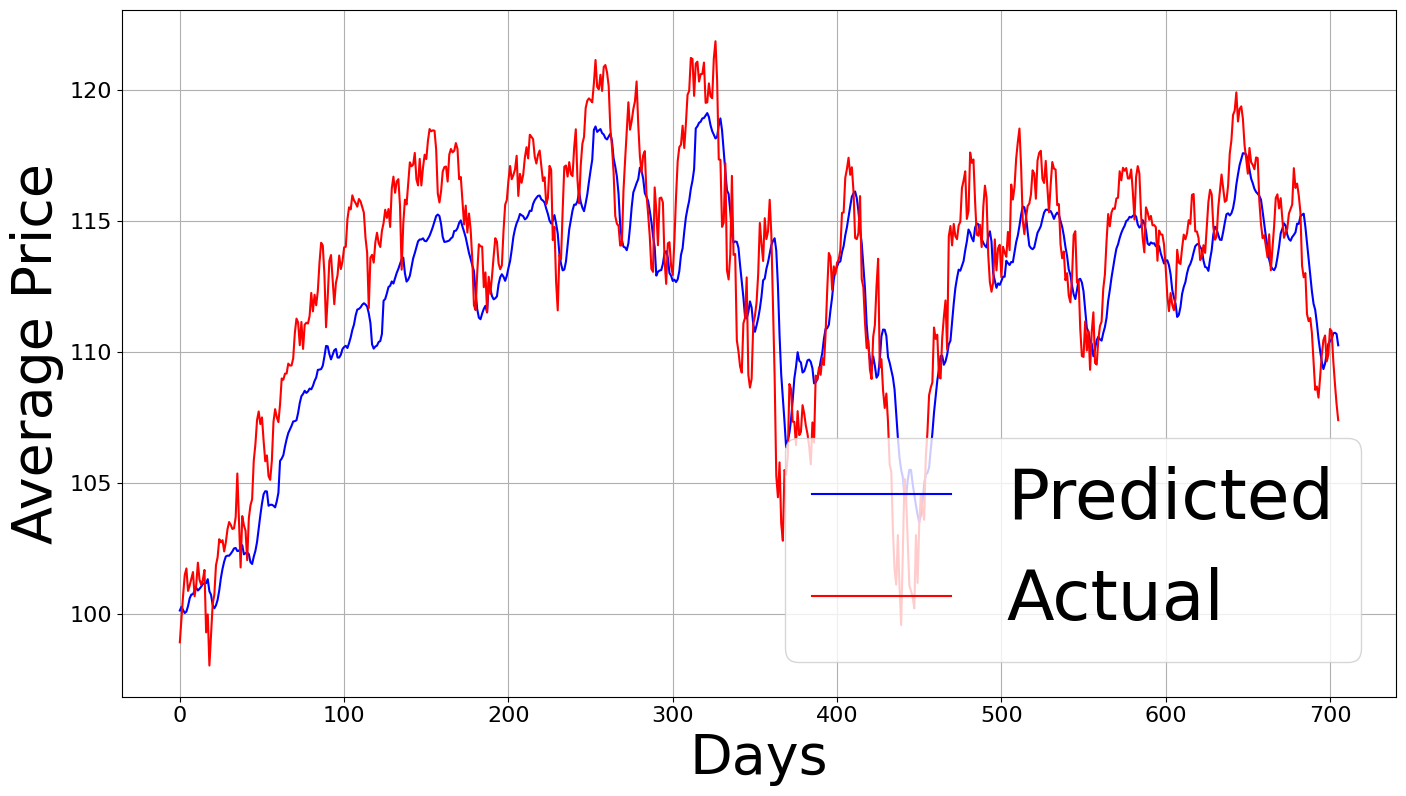

In [15]:
plot_average_predictions(predictions, actuals, PLOTS_DIR)

# LSTM quarterly rolling retrain

In [16]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_rolling'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_rolling'

In [ ]:
predictions, actuals = get_predictions_quarterly_models(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    model_folder=MODEL_DIR,
    data_start=quarterly_data_start_date,
    train_mode="rolling"
)

In [18]:
def calculate_rmse_for_all_tickers(actuals, predictions):
    rmse_values = {}
    for ticker in actuals.keys():
        actual = actuals[ticker]
        pred = predictions[ticker]
        rmse = sqrt(mean_squared_error(actual, pred))
        rmse_values[ticker] = rmse
        print(f"RMSE for {ticker}: {rmse}")
    return rmse_values

rmse_values = calculate_rmse_for_all_tickers(actuals, predictions)

RMSE for GOOGL: 6.940837142971015
RMSE for AMZN: 7.653894858359661
RMSE for AAPL: 6.2913453067342315
RMSE for PEP: 3.840906359112266
RMSE for JNJ: 3.3868686913662702
RMSE for PFE: 2.3886274951650988
RMSE for MRK: 2.0731103873940913
RMSE for ABBV: 5.146624090858824
RMSE for PG: 4.374652610871994
RMSE for KO: 1.4098049493526799
RMSE for WMT: 1.3969870857197149
RMSE for JPM: 10.675718591599054
RMSE for BAC: 2.5401760752471225
RMSE for GS: 14.526328027916538
RMSE for V: 6.071287797488956
RMSE for XOM: 4.081506474834519
RMSE for CVX: 9.10562364268218
RMSE for COP: 4.437925857766681
RMSE for BP: 0.986066310107617
RMSE for BA: 8.515574349391157
RMSE for MMM: 4.369654121989975
RMSE for HON: 5.799599396619427
RMSE for GE: 5.80388575603358
RMSE for T: 0.8015157451442434
RMSE for VZ: 1.0166824153946004
RMSE for TMUS: 4.643465070645345
RMSE for HSY: 6.016665343686864
RMSE for DUK: 2.626305583940978
RMSE for SO: 2.328509971581168
RMSE for EXC: 1.5082731192604935
RMSE for AEP: 3.5650536596136977
RMS

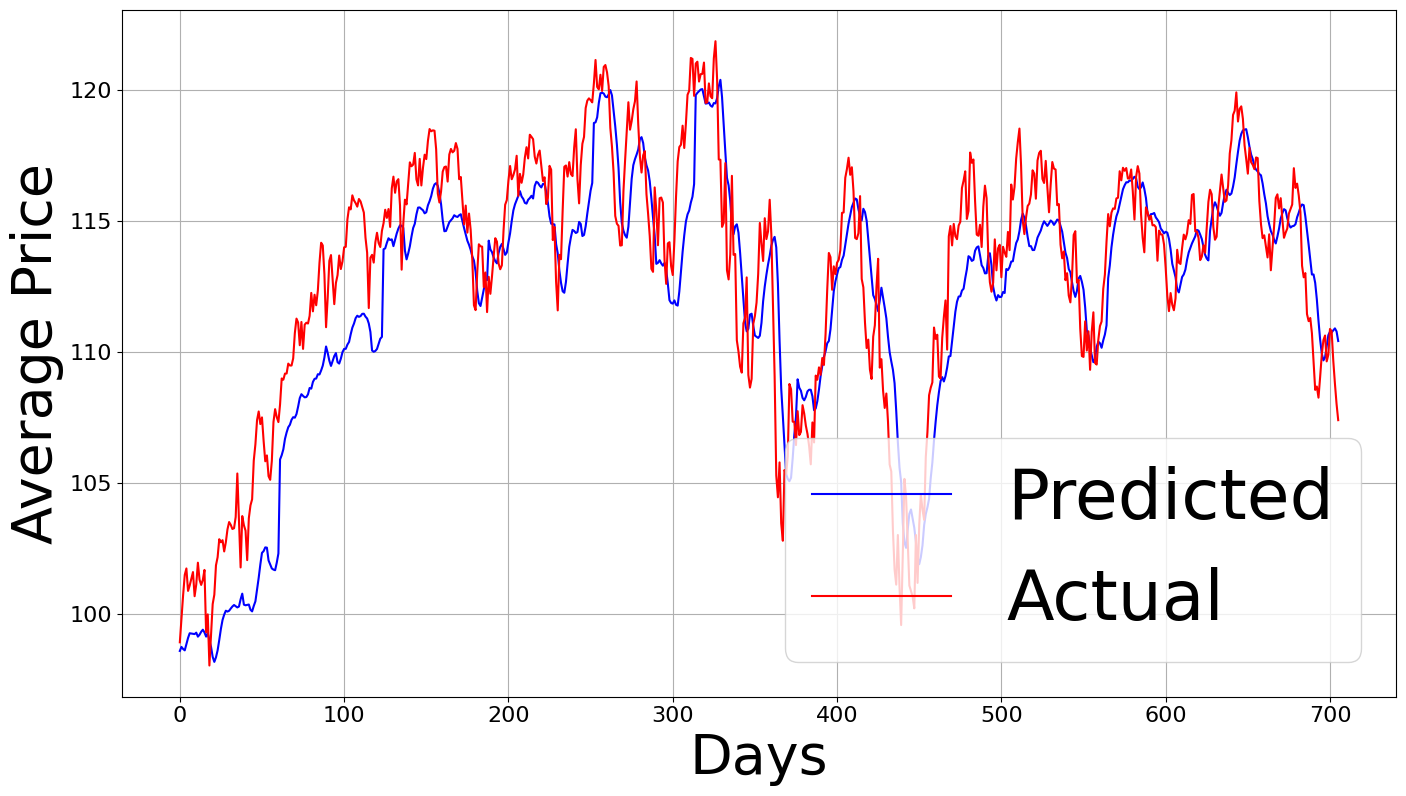

In [19]:
plot_average_predictions(predictions, actuals, PLOTS_DIR)